In [1]:
#import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [2]:
#load dataset
df = pd.read_csv("/content/credit_card_fraud_10k.csv")


df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
#basic information
print(df.shape)

print(df.info())


(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [5]:
print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [6]:
#remove duplicates
df.drop_duplicates(inplace=True)

print(df.shape)

(10000, 10)


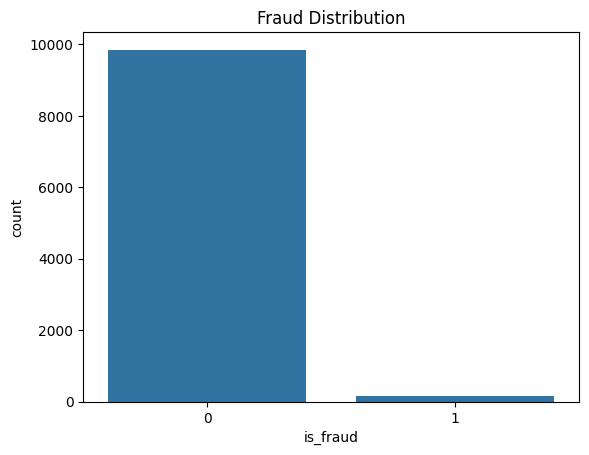

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [7]:
#class distribution
sns.countplot(x="is_fraud", data=df)

plt.title("Fraud Distribution")
plt.show()

print(df["is_fraud"].value_counts())

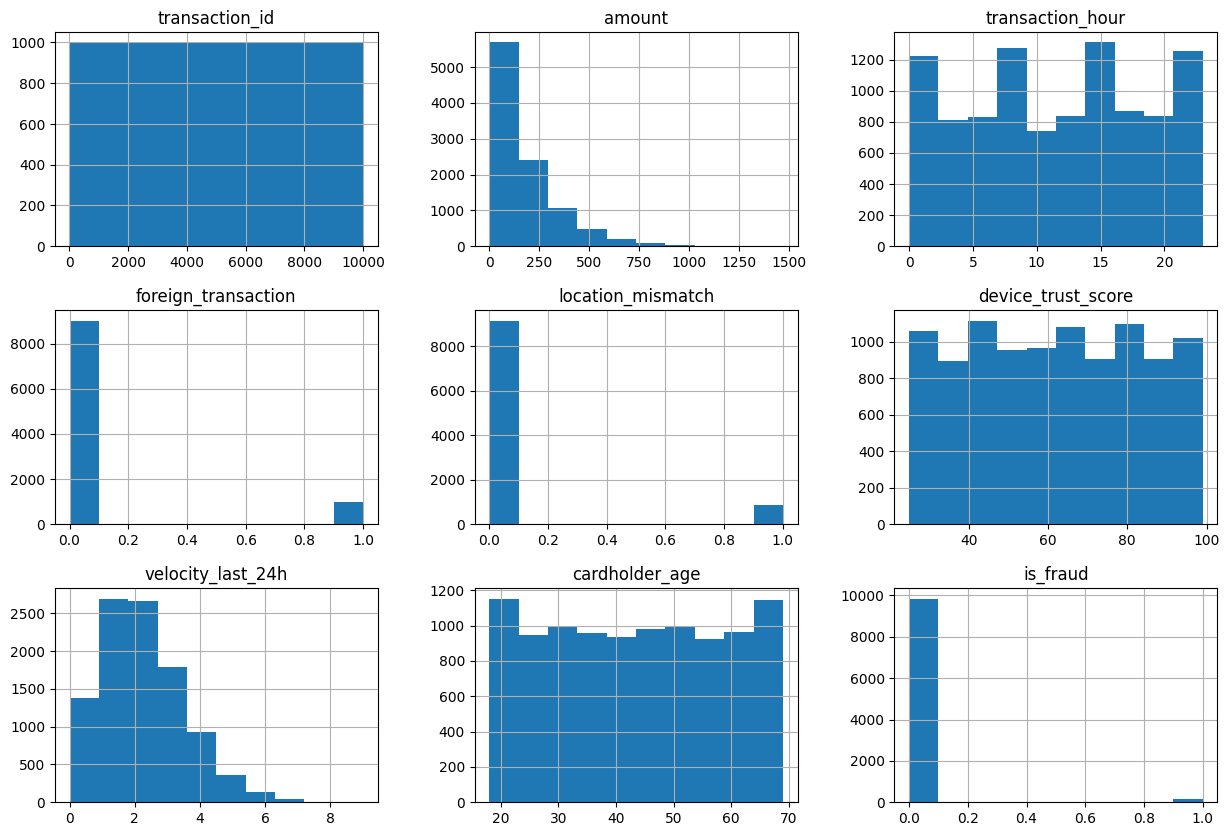

In [8]:
#histogram
df.hist(figsize=(15,10))

plt.show()

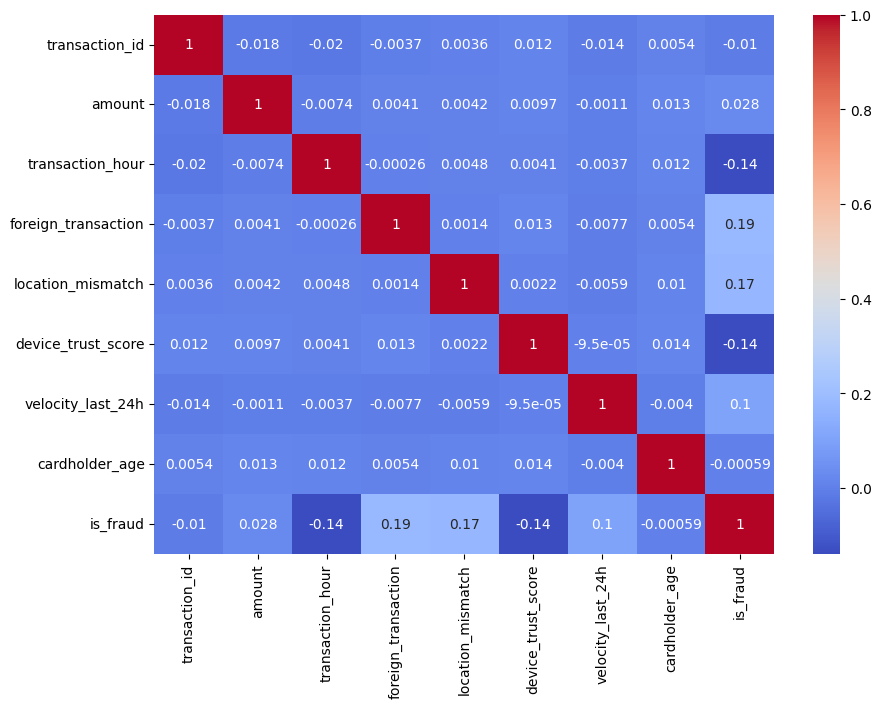

In [9]:
#correlation heatmap
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [10]:
#encoder catogarical column
encoder = LabelEncoder()

df["merchant_category"] = encoder.fit_transform(df["merchant_category"])

In [11]:
#seperate features
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

In [12]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
#apply smote
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

is_fraud
0    7879
1     121
Name: count, dtype: int64
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [14]:
#standard scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [15]:
#logistic regrission
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train_smote)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]


In [16]:
#logistic evalution
print(classification_report(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))

print("Recall :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

print("ROC AUC :", roc_auc_score(y_test, lr_prob))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94      1970
           1       0.11      1.00      0.20        30

    accuracy                           0.88      2000
   macro avg       0.56      0.94      0.57      2000
weighted avg       0.99      0.88      0.92      2000

Precision : 0.11152416356877323
Recall : 1.0
F1 Score : 0.20066889632107024
ROC AUC : 0.9911844331641286


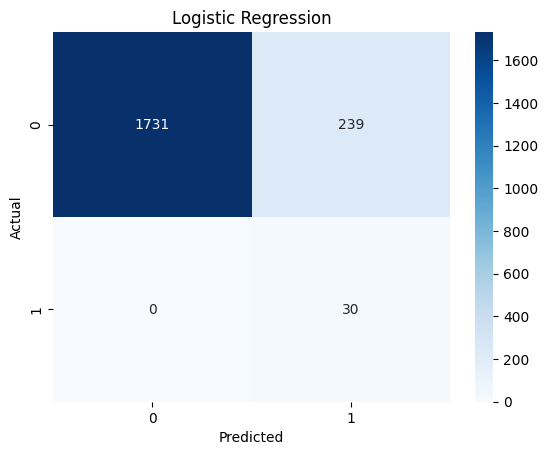

In [17]:
#logistic confussion matrix
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [18]:
#random forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [19]:
#random forest evokution
print(classification_report(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

print("ROC AUC :", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1970
           1       0.24      0.67      0.35        30

    accuracy                           0.96      2000
   macro avg       0.62      0.82      0.67      2000
weighted avg       0.98      0.96      0.97      2000

Precision : 0.24096385542168675
Recall : 0.6666666666666666
F1 Score : 0.35398230088495575
ROC AUC : 0.9798307952622674


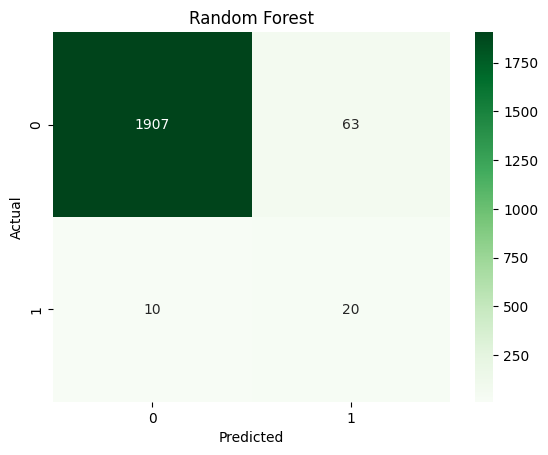

In [20]:
#random forest confussion matrix
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest")

plt.show()



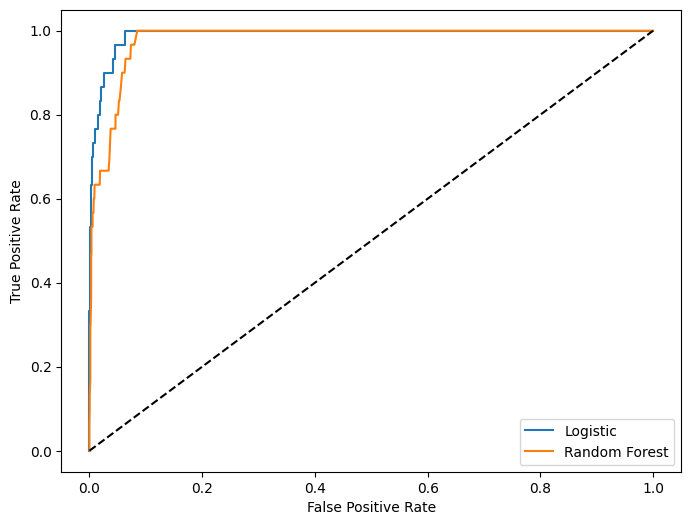

In [21]:
#ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [22]:
#hypereremeter tuning
params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid.fit(X_train_smote, y_train_smote)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.9771484690129645


In [23]:
#best model
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

best_prob = best_rf.predict_proba(X_test)[:,1]

In [24]:
#final evoution
print(classification_report(y_test, best_pred))

print("Precision :", precision_score(y_test,best_pred))

print("Recall :", recall_score(y_test,best_pred))

print("F1 :", f1_score(y_test,best_pred))

print("ROC AUC :", roc_auc_score(y_test,best_prob))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1970
           1       0.27      0.70      0.39        30

    accuracy                           0.97      2000
   macro avg       0.63      0.84      0.68      2000
weighted avg       0.98      0.97      0.97      2000

Precision : 0.26582278481012656
Recall : 0.7
F1 : 0.3853211009174312
ROC AUC : 0.9817005076142131


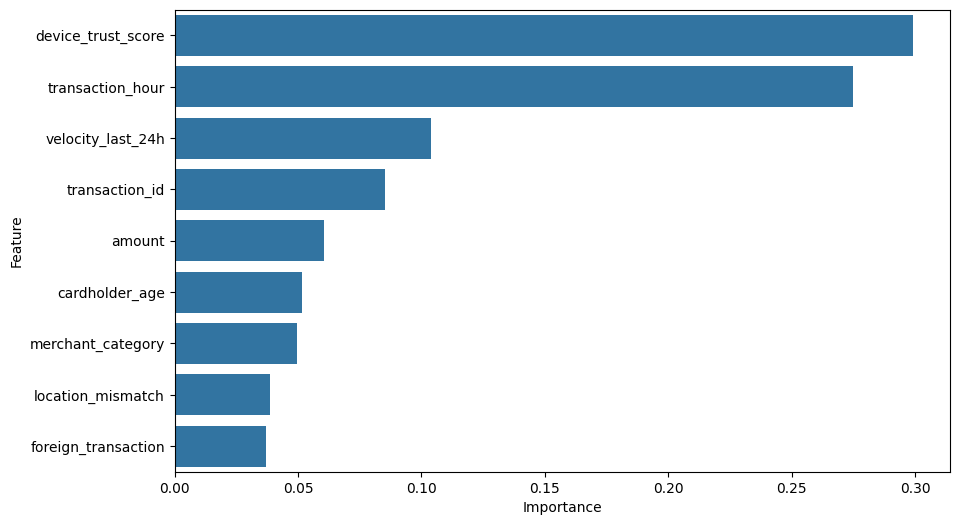

In [25]:
#feature importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance

)

plt.show()

In [26]:
#compare models
comparison = pd.DataFrame({

    "Model":["Logistic Regression","Random Forest"],

    "Precision":[

        precision_score(y_test,lr_pred),

        precision_score(y_test,rf_pred)

    ],

    "Recall":[

        recall_score(y_test,lr_pred),

        recall_score(y_test,rf_pred)

    ],

    "F1 Score":[

        f1_score(y_test,lr_pred),

        f1_score(y_test,rf_pred)

    ],

    "ROC AUC":[

        roc_auc_score(y_test,lr_prob),

        roc_auc_score(y_test,rf_prob)

    ]

})

print(comparison)

                 Model  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression   0.111524  1.000000  0.200669  0.991184
1        Random Forest   0.240964  0.666667  0.353982  0.979831
